In [7]:
# Multiple Linear Regression with Scikit-Learn

In [8]:
%pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# importing necessary libraries

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

In [10]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# load the dataset
df = pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [14]:
df.shape

(200, 5)

In [15]:
# show first few rows
df.head() 

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [17]:
# Column "Unnamed: 0" is just an index column, we can drop it
df.drop(["Unnamed: 0"], axis = 1, inplace = True)

In [18]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [20]:
# Check for missing values
print("Missing values in each column:")
df.isnull().sum().sort_values(ascending=False)

Missing values in each column:


TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [21]:
print("Data types of each columns:")
print(df.dtypes)

Data types of each columns:
TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object


In [22]:
print("Information about the dataset:")
df.info()

Information about the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [24]:
print("Summary statistics of the dataset:")
df.describe()

# Insight:
# 1. Most of the companies have a higher advertising budget for TV compared to Radio and Newspaper.
# 2. The lowest advertising budget is for radio.
# 2. The average sales is around 14.02 thousand units.

Summary statistics of the dataset:


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [25]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='str')

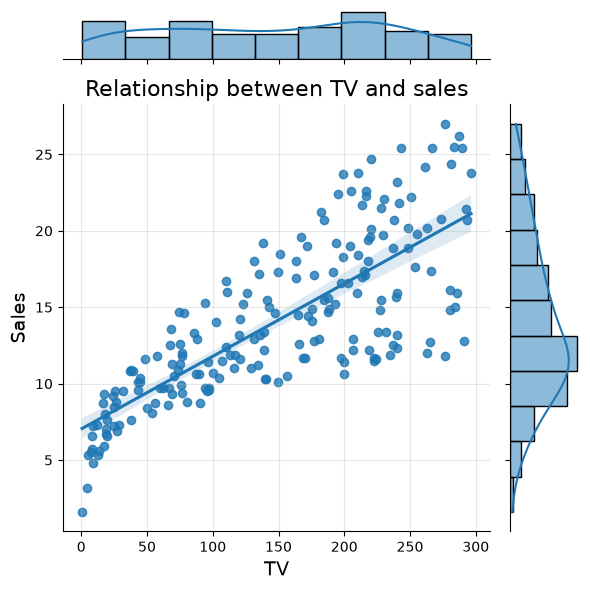

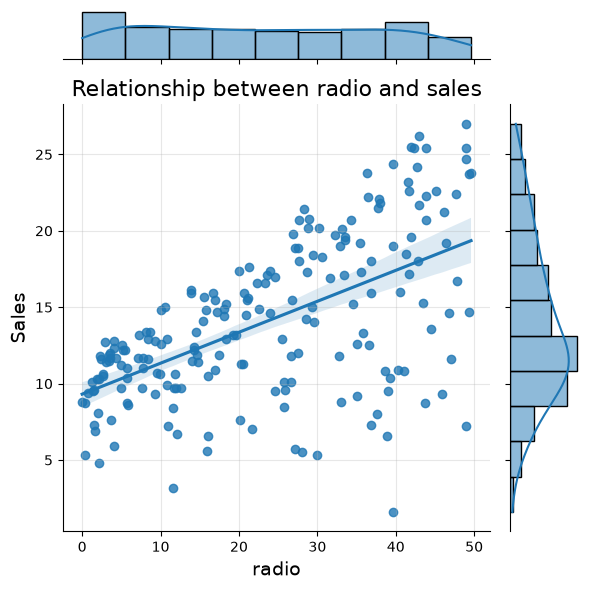

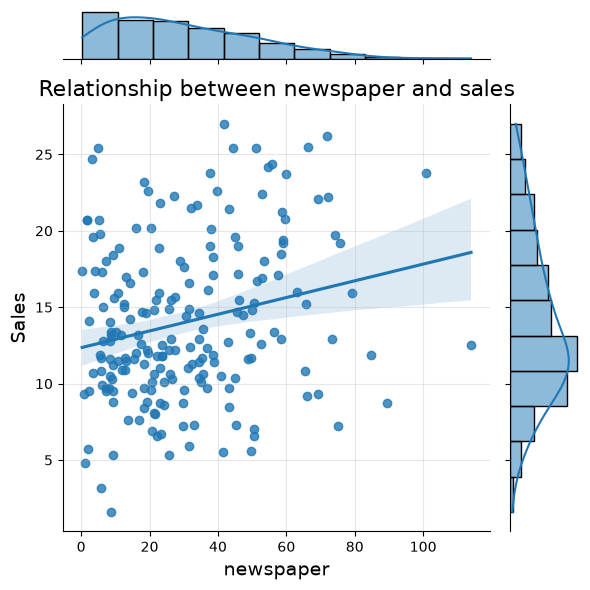

In [27]:
# Lets look at the relationship between the features (independent variables) and the target variable (dependent variable)

features = ['TV', 'radio', 'newspaper']

for feature in features:
    sns.jointplot(x=feature, y='sales', data=df, kind='reg')
    plt.title(f'Relationship between {feature} and sales', fontsize = 16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('Sales', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

In [28]:
# Insights from the above plots:
# 1. There is a strong positive linear relationship between TV advertising budget and sales.
# 2. There is a moderate positive linear relationship between Radio advertising budget and sales.
# 3. There is a weak positive linear relationship between Newspaper advertising budget and sales.
# This indicates that TV advertising has the most significant impact on sales, followed by Radio and Newspaper.

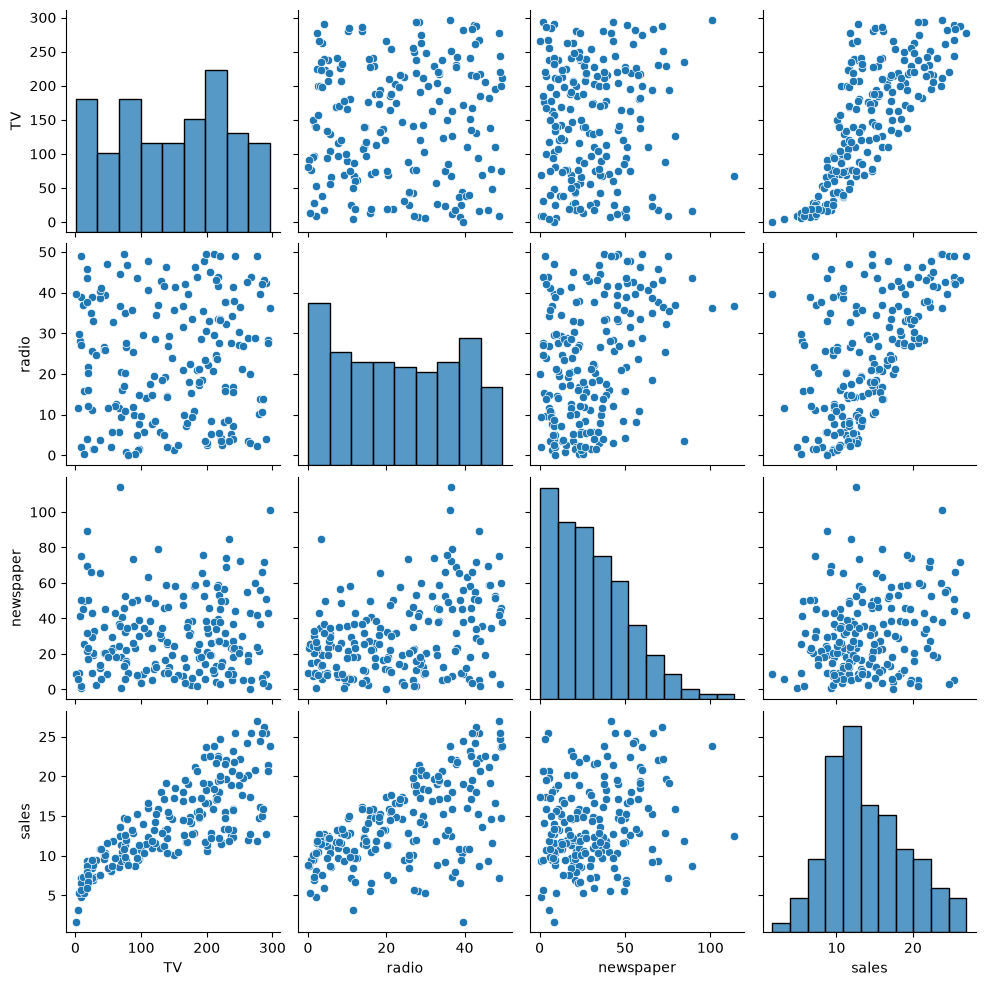

In [30]:
sns.pairplot(df)
plt.show()

In [31]:
# Multicollinearity Check
# We can check for multicollinearity using the correlation matrix

correlation_matrix = df.corr(numeric_only=True)
print("Correlation matrix:")
correlation_matrix

# Simple Layman Example:
# I stay in Mumbai and I have some work in Pune and hence I will be travelling to Pune.
# For travel, I prefer to use my own car.
# BUT: I have 3 cars (My car, My Wife's car, My Dad's car)
# Decision: I will take all the cars for my work.
# My car: I will drive it myself.
# My Wife's car: I will hire a driver to drive it.
# My Dad's car: I will hire another driver to drive it.
# Question: Is my decision correct?
# Answer: No, it is not correct. I should have taken only one car because all the cars are similar and they will take me to the same place.
# Lets assume:
# y - My Mumbai to Pune travel
# X1 - My car
# X2 - My Wife's car
# X3 - My Dad's car
# The relationship between y and X1, X2, X3 is linear.
# But we realize that X1, X2, X3 are highly correlated with each other and this is called multicollinearity.
# Multicollinearity can lead to overfitting and instability in the model.
# In this case, we will consider any one of the cars (X1, X2, or X3) and drop the rest. Thats how we will handle multicollinearity.

# So when do we say that multicollinearity is present?
# If the correlation between two or more independent variables is greater than 0.7 or lesser than -0.7, then we can say that multicollinearity is present.
# Note: Multicollinearity is always between independent variables.

Correlation matrix:


,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


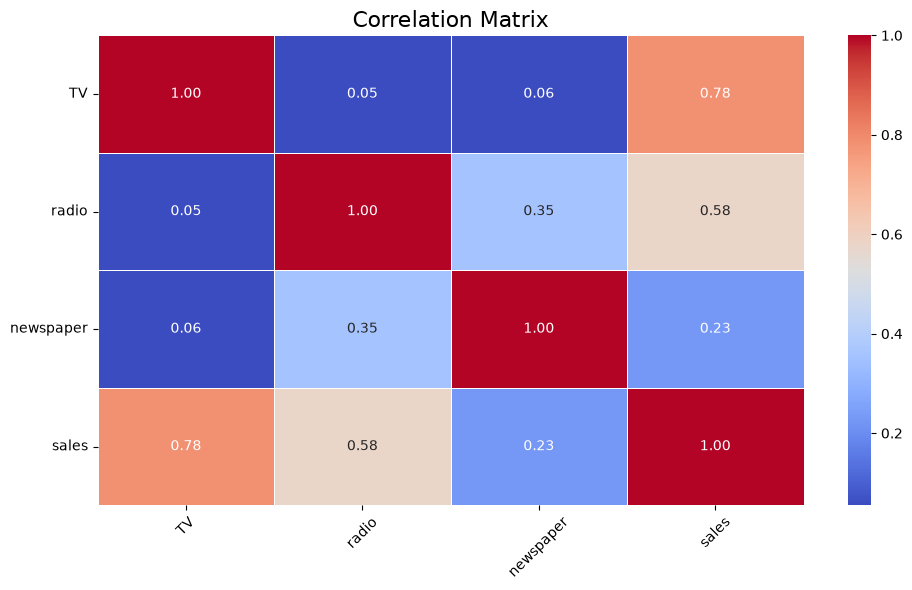

In [35]:
# Plot the correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# Insights from the correlation matrix:
# 1. There is a strong positive correlation between TV and Sales (0.78).
# 2. There is a moderate positive correlation between Radio and Sales (0.58).
# 3. There is a weak positive correlation between Newspaper and Sales (0.23).
# 4. There is no Multicollinearity between the independent variables (TV, Radio, Newspaper) as the correlation values are between -0.7 and 0.7.

### **Technical Explanation: What is Multicollinearity?**

**Multicollinearity** refers to a situation in multiple linear regression where **two or more independent variables (predictors) are highly correlated with each other**. This means that some predictors carry redundant information about the response variable. When multicollinearity is present, it becomes difficult for the regression model to accurately estimate the relationship between each predictor and the dependent variable.

---

### **Why is Multicollinearity a Problem?**

* It causes **instability in coefficient estimates**: small changes in data can lead to large changes in the estimated coefficients.
* It inflates the **standard errors of the coefficients**, making them statistically insignificant even if they are actually important.
* It reduces the **interpretability** of the model: you can’t tell which predictor is truly responsible for changes in the target.
* It may lead to **overfitting** in some cases.

---

### **How is Multicollinearity Detected?**

| Method                                | What to Look For                                                       | Acceptable Value Range                   |
| ------------------------------------- | ---------------------------------------------------------------------- | ---------------------------------------- |
| **Correlation Matrix**                | Correlation between predictors                                         | Preferably below ±0.7                    |
| **Variance Inflation Factor (VIF)**   | How much the variance of a coefficient is inflated due to collinearity | VIF < 5 acceptable; VIF > 10 problematic |
| **Condition Number**                  | Ratio of largest to smallest singular values                           | < 30 generally acceptable                |
| **Eigenvalues of correlation matrix** | Small eigenvalues indicate collinearity                                | No strict rule; interpret with caution   |

---

### **Acceptable Correlation Values in Business Context**

| Business Example                            | Independent Variables                       | Acceptable Correlation | Typical Decision                                         |
| ------------------------------------------- | ------------------------------------------- | ---------------------- | -------------------------------------------------------- |
| **Marketing: Sales Prediction**             | TV, Radio, Newspaper spend                  | < 0.7                  | Drop or combine highly correlated channels               |
| **Finance: Credit Scoring**                 | Income, Savings, Investment Amount          | < 0.7                  | Remove/reduce one of the correlated financial indicators |
| **Manufacturing: Production Rate Forecast** | Machine Hours, Labor Hours, Power Usage     | < 0.7                  | Keep most meaningful metric, remove redundant            |
| **Retail: Customer Spend Modeling**         | Loyalty points, Purchase frequency, Recency | < 0.7                  | Use PCA or remove less predictive features               |
| **Logistics: Delivery Time Prediction**     | Distance, Fuel Usage, Travel Time           | < 0.7                  | Remove one or use combined metric like Efficiency        |

---

### **How Decisions Are Taken in Practice**

| Scenario                                             | Technical Action                                             | Business Decision                                    |
| ---------------------------------------------------- | ------------------------------------------------------------ | ---------------------------------------------------- |
| Correlation between predictors is low (< 0.5)        | No action needed                                             | Keep all predictors                                  |
| Correlation is moderate (0.5 to 0.7)                 | Carefully examine; may keep if business logic differs        | Keep both if they capture different aspects          |
| Correlation is high (> 0.7)                          | Remove one, or apply dimensionality reduction (PCA)          | Keep only the feature with higher business relevance |
| VIF > 5 but < 10                                     | Investigate, may drop if redundancy confirmed                | Focus on simplifying the model                       |
| VIF > 10                                             | Strong evidence of multicollinearity; remove/reduce feature  | Remove to avoid misleading predictions               |
| Highly correlated but essential for interpretability | Keep both, accept some collinearity but caution on inference | For explanatory models, accept trade-off             |

---

### **Real-World Example**

#### Example 1: Marketing Campaign Spend

* TV spend and Radio spend are correlated at **0.82**.
* Decision: Drop Radio spend or build a combined 'Media Spend' variable.

#### Example 2: Manufacturing

* Machine A runtime and power consumption have a correlation of **0.91**.
* Decision: Keep machine runtime and drop power consumption from the model, as runtime drives production.

#### Example 3: Retail

* Customer visits and purchases are correlated at **0.65**.
* Decision: Keep both, as visits and purchases capture separate aspects of customer behavior.

---

### **Conclusion**

Multicollinearity does not affect **prediction accuracy** directly but it affects **model interpretability and stability**. If your goal is forecasting, you may tolerate some multicollinearity. But if your goal is to explain relationships, it must be addressed.

---



In [39]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [40]:
features = ['TV', 'radio', 'newspaper']
X = df[features] # independent variable
y = df['sales'] # dependent variable

In [41]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [42]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [43]:
df.shape

(200, 4)

In [48]:
%pip install scikit-learn

     ---------------------------------------- 0.0/61.2 kB ? eta -:--:--
     ---------------------------------------- 61.2/61.2 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 33.4 MB/s eta 0:00:01
   ------------ --------------------------- 2.7/8.3 MB 34.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.3 MB 27.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.3/8.3 MB 24.9 MB/s eta 0:00:01
   -------------------------- ------------- 5.6/8.3 MB 25.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------  8.3/8.3 MB 27.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 23.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   --------------------------------------- 306.1/306.1 kB 19.7 MB/s eta 0:00:00
   ---------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# Lets split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (160, 3)
Shape of X_test: (40, 3)
Shape of y_train: (160,)
Shape of y_test: (40,)


In [50]:
X_train.head()

,TV,radio,newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6


In [51]:
X_train.describe()

,TV,radio,newspaper
count,160.000000,160.000000,160.000000
mean,150.019375,22.875625,29.945625
std,84.418857,14.805216,20.336449
min,0.700000,0.000000,0.300000
25%,77.750000,9.825000,12.875000
50%,150.650000,21.200000,25.600000
75%,218.825000,36.425000,44.500000
max,296.400000,49.600000,100.900000


#Feature scaling 

In [54]:
# Scaling the independent variables

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[features] = sc.fit_transform(X_train[features])      # fit - study, transform - apply the transformation

# transform - apply the same. Why not fit (i.e. study) on the test set? Because it already has studied the training set and we want to apply the same transformation on the test set. This will help us to see how the model performs on unseen data.
X_test[features] = sc.transform(X_test[features])

In [55]:
X_train.describe()

,TV,radio,newspaper
count,1.600000e+02,1.600000e+02,1.600000e+02
mean,-2.942091e-16,-2.081668e-16,1.665335e-17
std,1.003140e+00,1.003140e+00,1.003140e+00
min,-1.774345e+00,-1.549957e+00,-1.462335e+00
25%,-8.587688e-01,-8.842559e-01,-8.420458e-01
50%,7.493646e-03,-1.135334e-01,-2.143574e-01
75%,8.176095e-01,9.180491e-01,7.179263e-01
max,1.739424e+00,1.810732e+00,3.499979e+00


In [57]:
X_test.describe()

,TV,radio,newspaper
count,40.000000,40.000000,40.000000
mean,-0.176869,0.131573,0.150047
std,1.087436,1.023122,1.329547
min,-1.718496,-1.441548,-1.432739
25%,-1.157326,-0.753826,-0.901238
50%,-0.126189,0.303165,-0.150232
75%,0.803944,0.924825,0.844944
max,1.697834,1.797181,4.146165


In [60]:
# Modeling

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions on the training and testing sets

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)


# Evaluate the model performance using appropriate metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training set evaluation
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

# Adjusted R-squared
# https://miro.medium.com/v2/resize:fit:1024/1*kW2xSxbIb7laGRoEcgx8vg.jpeg
n_train = X_train.shape[0]  # Number of observations in training set
p_train = X_train.shape[1]  # Number of features in training set
num_train = (1 - r2_train) * (n_train - 1)
denom_train = n_train - p_train - 1
adj_r2_train = 1 - (num_train / denom_train)

# Testing set evaluation
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

# Adjusted R-squared
n_test = X_test.shape[0]  # Number of observations in testing set
p_test = X_test.shape[1]  # Number of features in testing set
num_test = (1 - r2_test) * (n_test - 1)
denom_test = n_test - p_test - 1
adj_r2_test = 1 - (num_test / denom_test)

# Print the evaluation metrics
print("Training and Testing Set Evaluation Metrics:")
print(f"Training Set - MAE: {mae_train}, Testing Set - MAE: {mae_test}")
print(f"Training Set - MSE: {mse_train}, Testing Set - MSE: {mse_test}")
print(f"Training Set - RMSE: {rmse_train}, Testing Set - RMSE: {rmse_test}")
print(f"Training Set - R-squared: {r2_train}, Testing Set - R-squared: {r2_test}")
print(f"Training Set - Adjusted R-squared: {adj_r2_train}, Testing Set - Adjusted R-squared: {adj_r2_test}")

Training and Testing Set Evaluation Metrics:
Training Set - MAE: 1.1984678961500133, Testing Set - MAE: 1.4607567168117601
Training Set - MSE: 2.7051294230814142, Testing Set - MSE: 3.1740973539761073
Training Set - RMSE: 1.6447277656443373, Testing Set - RMSE: 1.781599661533451
Training Set - R-squared: 0.8957008271017817, Testing Set - R-squared: 0.8994380241009119
Training Set - Adjusted R-squared: 0.8936950737768159, Testing Set - Adjusted R-squared: 0.8910578594426546


In [61]:
# Printing the coefficients of the model
print("\nCoefficients of the model:")

for feature, coef in zip(features, lr.coef_):
    print(f"{feature}: {coef}")
    
# Printing the intercept of the model
print(f"Intercept: {lr.intercept_}")

# Printing the equation of the model
equation = "Sales = {} + {}*TV + {}*Radio + {}*Newspaper".format(
    lr.intercept_,
    lr.coef_[0],
    lr.coef_[1],
    lr.coef_[2]
)

print("\nEquation of the model:")
print(equation)

# Sales = 14.10 + 3.76*TV + 2.79*Radio + 0.06*Newspaper
# We understand that for every 1 unit increase in TV advertising budget, sales increases by 3.76 units, for every 1 unit increase in Radio advertising budget, sales increases by 2.79 units, and for every 1 unit increase in Newspaper advertising budget, sales increases by 0.06 units.


Coefficients of the model:
TV: 3.7641961751469957
radio: 2.792306650198436
newspaper: 0.05597551446265259
Intercept: 14.100000000000001

Equation of the model:
Sales = 14.100000000000001 + 3.7641961751469957*TV + 2.792306650198436*Radio + 0.05597551446265259*Newspaper
